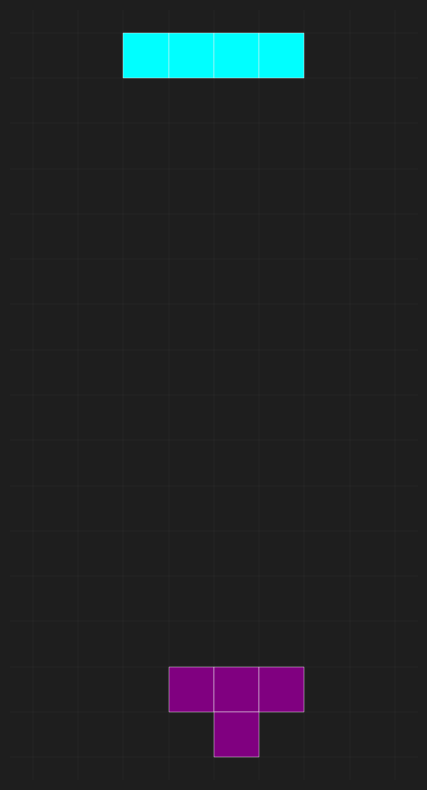

<IPython.core.display.Javascript object>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import ipywidgets as widgets
from IPython.display import display, clear_output
import time

class Tetris:
    def __init__(self, width=8, height=16):  # Smaller board for mobile
        self.width = width
        self.height = height
        self.board = np.zeros((height, width), dtype=int)
        self.score = 0
        self.level = 1
        self.lines_cleared = 0
        self.game_over = False
        self.paused = False
        
        # Tetromino shapes and colors
        self.shapes = [
            [[1, 1, 1, 1]],  # I
            [[1, 1], [1, 1]],  # O
            [[1, 1, 1], [0, 1, 0]],  # T
            [[1, 1, 1], [1, 0, 0]],  # J
            [[1, 1, 1], [0, 0, 1]],  # L
            [[0, 1, 1], [1, 1, 0]],  # S
            [[1, 1, 0], [0, 1, 1]]   # Z
        ]
        
        self.colors = [
            '#00FFFF',  # cyan
            '#FFFF00',  # yellow  
            '#800080',  # purple
            '#0000FF',  # blue
            '#FFA500',  # orange
            '#00FF00',  # green
            '#FF0000'   # red
        ]
        
        self.current_piece = None
        self.current_color = None
        self.current_x = 0
        self.current_y = 0
        
        self.new_piece()
        self.last_drop_time = time.time()
        
    def new_piece(self):
        shape_idx = np.random.randint(len(self.shapes))
        self.current_piece = np.array(self.shapes[shape_idx])
        self.current_color = self.colors[shape_idx]
        
        self.current_x = self.width // 2 - len(self.current_piece[0]) // 2
        self.current_y = 0
        
        if self.check_collision():
            self.game_over = True
    
    def check_collision(self):
        for y in range(len(self.current_piece)):
            for x in range(len(self.current_piece[0])):
                if self.current_piece[y][x]:
                    board_x = self.current_x + x
                    board_y = self.current_y + y
                    
                    if (board_x < 0 or board_x >= self.width or 
                        board_y >= self.height or 
                        (board_y >= 0 and self.board[board_y][board_x])):
                        return True
        return False
    
    def merge_piece(self):
        for y in range(len(self.current_piece)):
            for x in range(len(self.current_piece[0])):
                if self.current_piece[y][x]:
                    board_x = self.current_x + x
                    board_y = self.current_y + y
                    if 0 <= board_y < self.height and 0 <= board_x < self.width:
                        self.board[board_y][board_x] = self.colors.index(self.current_color) + 1
    
    def rotate_piece(self):
        rotated = np.rot90(self.current_piece)
        original_piece = self.current_piece.copy()
        self.current_piece = rotated
        
        if self.check_collision():
            self.current_piece = original_piece
    
    def move(self, dx, dy):
        self.current_x += dx
        self.current_y += dy
        
        if self.check_collision():
            self.current_x -= dx
            self.current_y -= dy
            
            if dy > 0:
                self.merge_piece()
                self.clear_lines()
                self.new_piece()
                self.score += 10
    
    def drop(self):
        while not self.check_collision():
            self.current_y += 1
        self.current_y -= 1
        self.merge_piece()
        self.clear_lines()
        self.new_piece()
        self.score += 20
    
    def clear_lines(self):
        lines_to_clear = []
        for y in range(self.height):
            if all(self.board[y]):
                lines_to_clear.append(y)
        
        for line in lines_to_clear:
            self.board = np.delete(self.board, line, axis=0)
            self.board = np.vstack([np.zeros(self.width, dtype=int), self.board])
        
        if lines_to_clear:
            self.lines_cleared += len(lines_to_clear)
            self.score += [100, 300, 500, 800][min(len(lines_to_clear)-1, 3)] * self.level
            self.level = self.lines_cleared // 10 + 1
    
    def auto_drop(self):
        current_time = time.time()
        drop_interval = max(0.5 - (self.level - 1) * 0.05, 0.1)
        
        if current_time - self.last_drop_time > drop_interval and not self.paused and not self.game_over:
            self.move(0, 1)
            self.last_drop_time = current_time
            return True
        return False

# Create game instance
tetris = Tetris()

# Create output widget for display
output = widgets.Output()

# Mobile-optimized button styling
button_layout = widgets.Layout(
    width='80px', 
    height='50px',
    margin='2px'
)

button_style = {
    'font_weight': 'bold',
    'font_size': '14px'
}

# Create compact buttons
left_btn = widgets.Button(description="←", layout=button_layout, style=button_style)
right_btn = widgets.Button(description="→", layout=button_layout, style=button_style)
down_btn = widgets.Button(description="↓", layout=button_layout, style=button_style)
rotate_btn = widgets.Button(description="↻", layout=button_layout, style=button_style)
drop_btn = widgets.Button(description="💣", layout=button_layout, style=button_style)
pause_btn = widgets.Button(description="⏸️", layout=button_layout, style=button_style)
restart_btn = widgets.Button(description="🔄", layout=button_layout, style=button_style)

# Button handlers
def on_left(b):
    if not tetris.game_over and not tetris.paused:
        tetris.move(-1, 0)
        update_display()

def on_right(b):
    if not tetris.game_over and not tetris.paused:
        tetris.move(1, 0)
        update_display()

def on_down(b):
    if not tetris.game_over and not tetris.paused:
        tetris.move(0, 1)
        update_display()

def on_rotate(b):
    if not tetris.game_over and not tetris.paused:
        tetris.rotate_piece()
        update_display()

def on_drop(b):
    if not tetris.game_over and not tetris.paused:
        tetris.drop()
        update_display()

def on_pause(b):
    tetris.paused = not tetris.paused
    pause_btn.description = "▶️" if tetris.paused else "⏸️"
    update_display()

def on_restart(b):
    global tetris
    tetris = Tetris()
    pause_btn.description = "⏸️"
    update_display()

# Connect buttons
left_btn.on_click(on_left)
right_btn.on_click(on_right)
down_btn.on_click(on_down)
rotate_btn.on_click(on_rotate)
drop_btn.on_click(on_drop)
pause_btn.on_click(on_pause)
restart_btn.on_click(on_restart)

# Create compact button layout for mobile
dpad_buttons = widgets.VBox([
    widgets.HBox([widgets.Label(value=""), rotate_btn, widgets.Label(value="")]),
    widgets.HBox([left_btn, down_btn, right_btn]),
    widgets.HBox([widgets.Label(value=""), drop_btn, widgets.Label(value="")])
])

control_buttons = widgets.HBox([pause_btn, restart_btn])

# Score display
score_display = widgets.HTML(
    value=f"<div style='text-align: center; font-size: 16px; font-weight: bold;'>"
          f"Score: <span style='color: #FFD700;'>{tetris.score}</span> | "
          f"Level: <span style='color: #00FF00;'>{tetris.level}</span></div>"
)

# Display function
def update_display():
    with output:
        clear_output(wait=True)
        
        # Update score display
        score_display.value = f"<div style='text-align: center; font-size: 16px; font-weight: bold;'>" \
                             f"Score: <span style='color: #FFD700;'>{tetris.score}</span> | " \
                             f"Level: <span style='color: #00FF00;'>{tetris.level}</span></div>"
        
        # Create smaller figure for mobile
        fig, ax = plt.subplots(figsize=(5, 8))  # Smaller figure
        fig.patch.set_facecolor('#1E1E1E')
        ax.set_facecolor('#1E1E1E')
        
        # Draw board
        for y in range(tetris.height):
            for x in range(tetris.width):
                if tetris.board[y][x]:
                    color_idx = tetris.board[y][x] - 1
                    rect = Rectangle((x, tetris.height - y - 1), 1, 1, 
                                    facecolor=tetris.colors[color_idx], 
                                    edgecolor='white', linewidth=0.3)
                    ax.add_patch(rect)
        
        # Draw current piece
        if not tetris.game_over and tetris.current_piece is not None:
            for y in range(len(tetris.current_piece)):
                for x in range(len(tetris.current_piece[0])):
                    if tetris.current_piece[y][x]:
                        rect = Rectangle((tetris.current_x + x, tetris.height - (tetris.current_y + y) - 1), 
                                        1, 1, facecolor=tetris.current_color, 
                                        edgecolor='white', linewidth=0.3)
                        ax.add_patch(rect)
        
        # Draw grid
        for x in range(tetris.width + 1):
            ax.axvline(x, color='gray', linewidth=0.1, alpha=0.5)
        for y in range(tetris.height + 1):
            ax.axhline(y, color='gray', linewidth=0.1, alpha=0.5)
        
        # Set limits and remove axes
        ax.set_xlim(-0.5, tetris.width + 0.5)
        ax.set_ylim(-0.5, tetris.height + 0.5)
        ax.set_aspect('equal')
        ax.axis('off')
        
        # Game over or paused text
        if tetris.game_over:
            ax.text(tetris.width/2, tetris.height/2, 'GAME OVER', 
                   color='red', fontsize=16, fontweight='bold', ha='center',
                   bbox=dict(boxstyle="round,pad=0.3", facecolor='black', alpha=0.8))
        elif tetris.paused:
            ax.text(tetris.width/2, tetris.height/2, 'PAUSED', 
                   color='yellow', fontsize=16, fontweight='bold', ha='center',
                   bbox=dict(boxstyle="round,pad=0.3", facecolor='black', alpha=0.8))
        
        plt.tight_layout()
        plt.show()

# Initial display
update_display()

# Create main container with everything in vertical order
main_container = widgets.VBox([
    widgets.HTML("<h3 style='text-align: center; color: #FFFFFF;'>🎮 MOBILE TETRIS 🎮</h3>"),
    score_display,
    output,
    widgets.HTML("<div style='text-align: center; color: #CCCCCC; font-size: 12px;'>Use buttons below or keyboard arrows</div>"),
    dpad_buttons,
    control_buttons,
    widgets.HTML("<div style='text-align: center; color: #888888; font-size: 10px; margin-top: 10px;'>Tap buttons to play!</div>")
], layout=widgets.Layout(
    align_items='center',
    padding='10px'
))

# Display everything in one container
display(main_container)

# Auto-drop loop
import threading

def game_loop():
    while True:
        if tetris.auto_drop():
            update_display()
        time.sleep(0.05)

# Start the game loop in a separate thread
game_thread = threading.Thread(target=game_loop, daemon=True)
game_thread.start()

# Keyboard controls
from IPython.display import Javascript

display(Javascript("""
// Add keyboard event listener
document.addEventListener('keydown', function(event) {
    var key = event.key;
    if (['ArrowLeft', 'ArrowRight', 'ArrowDown', 'ArrowUp', ' ', 'p', 'r'].includes(key)) {
        IPython.notebook.kernel.execute("handle_keyboard_event('" + key + "')");
        event.preventDefault();
    }
});

// Prevent scrolling when tapping buttons
document.addEventListener('touchstart', function(e) {
    if (e.target.tagName === 'BUTTON') {
        e.preventDefault();
    }
}, { passive: false });
"""))

# Keyboard event handler
def handle_keyboard_event(key):
    if key == 'ArrowLeft':
        on_left(None)
    elif key == 'ArrowRight':
        on_right(None)
    elif key == 'ArrowDown':
        on_down(None)
    elif key == 'ArrowUp':
        on_rotate(None)
    elif key == ' ':
        on_drop(None)
    elif key == 'p':
        on_pause(None)
    elif key == 'r':
        on_restart(None)